# RQ5 — Sensitivity to Evaluation Metrics

**Research Question:** How does the relative ranking of candidate models change when different evaluation metrics are considered?

**Expected Results:** Model rankings are expected to vary across metrics, showing that metric choice can influence which model appears best.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print('Libraries loaded.')


Libraries loaded.


## 1. Load, Preprocess & Evaluate All Models

In [ ]:
df = pd.read_csv('../data/ai_job_dataset1.csv')
DROP_COLS = ['job_id','salary_local','salary_currency','company_name','posting_date','application_deadline']
df_m = df.drop(columns=DROP_COLS)
df_m['num_skills'] = df_m['required_skills'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0)
df_m = df_m.drop(columns=['required_skills'])
CAT_COLS = ['job_title','experience_level','employment_type','company_location',
            'company_size','employee_residence','education_required','industry']
for col in CAT_COLS:
    le = LabelEncoder()
    df_m[col] = le.fit_transform(df_m[col].astype(str))
X = df_m.drop(columns=['salary_usd'])
y = df_m['salary_usd']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

models = {
    'Linear Reg':     Pipeline([('sc', StandardScaler()), ('m', LinearRegression())]),
    'Ridge':          Pipeline([('sc', StandardScaler()), ('m', Ridge())]),
    'Decision Tree':  Pipeline([('sc', StandardScaler()), ('m', DecisionTreeRegressor(max_depth=8, random_state=SEED))]),
    'KNN':            Pipeline([('sc', StandardScaler()), ('m', KNeighborsRegressor(n_neighbors=10, n_jobs=-1))]),
    'SVR':            Pipeline([('sc', StandardScaler()), ('m', SVR(kernel='rbf', C=100, epsilon=5000))]),
    'Grad Boosting':  Pipeline([('sc', StandardScaler()), ('m', GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=SEED))]),
    'XGBoost':        Pipeline([('sc', StandardScaler()), ('m', xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=SEED, n_jobs=-1, verbosity=0))]),
    'LightGBM':       Pipeline([('sc', StandardScaler()), ('m', lgb.LGBMRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=SEED, n_jobs=-1, verbose=-1))]),
}

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

def mdae(y_true, y_pred):
    return np.median(np.abs(y_true - y_pred))

metrics_raw = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    metrics_raw[name] = {
        'R²':      r2_score(y_test, y_pred),
        'MAE':     mean_absolute_error(y_test, y_pred),
        'RMSE':    np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAPE (%)':mape(y_test.values, y_pred),
        'MdAE':    mdae(y_test.values, y_pred),
    }
    print(f'{name:14s} | R²={metrics_raw[name]["R²"]:.4f}')

metrics_df = pd.DataFrame(metrics_raw).T.round(2)
metrics_df


Linear Reg     | R²=0.6313
Ridge          | R²=0.6313
Decision Tree  | R²=0.8729
KNN            | R²=0.6531
SVR            | R²=0.3067
Grad Boosting  | R²=0.8880
XGBoost        | R²=0.8839
LightGBM       | R²=0.8863


,R²,MAE,RMSE,MAPE (%),MdAE
Linear Reg,0.63,27179.63,38436.08,28.40,18727.24
Ridge,0.63,27179.59,38436.17,28.40,18725.20
Decision Tree,0.87,16028.39,22571.88,12.94,11466.43
KNN,0.65,26904.06,37284.18,27.91,18881.95
SVR,0.31,36575.59,52710.44,35.62,23657.74
Grad Boosting,0.89,15317.58,21184.80,12.53,11068.42
XGBoost,0.88,15491.77,21565.20,12.60,11244.81
LightGBM,0.89,15422.99,21343.73,12.56,11171.34


## 2. Table V — Model Rankings Under Different Metrics

In [ ]:
rank_df = pd.DataFrame({
    'Rank by R²':       metrics_df['R²'].rank(ascending=False).astype(int),
    'Rank by MAE':      metrics_df['MAE'].rank(ascending=True).astype(int),
    'Rank by RMSE':     metrics_df['RMSE'].rank(ascending=True).astype(int),
    'Rank by MAPE':     metrics_df['MAPE (%)'].rank(ascending=True).astype(int),
    'Rank by MdAE':     metrics_df['MdAE'].rank(ascending=True).astype(int),
})
rank_df['Mean Rank'] = rank_df.mean(axis=1).round(1)
rank_df = rank_df.sort_values('Mean Rank')
print('Table V. Model ranking under different evaluation metrics (1 = best)')
rank_df


Table V. Model ranking under different evaluation metrics (1 = best)


,Rank by R²,Rank by MAE,Rank by RMSE,Rank by MAPE,Rank by MdAE,Mean Rank
Grad Boosting,1,1,1,1,1,1.0
LightGBM,1,2,2,2,2,1.8
XGBoost,3,3,3,3,3,3.0
Decision Tree,4,4,4,4,4,4.0
KNN,5,5,5,5,7,5.4
Ridge,6,6,7,6,5,6.0
Linear Reg,6,7,6,6,6,6.2
SVR,8,8,8,8,8,8.0


## 3. Figure 5A — Grouped Bar Chart of Ranks

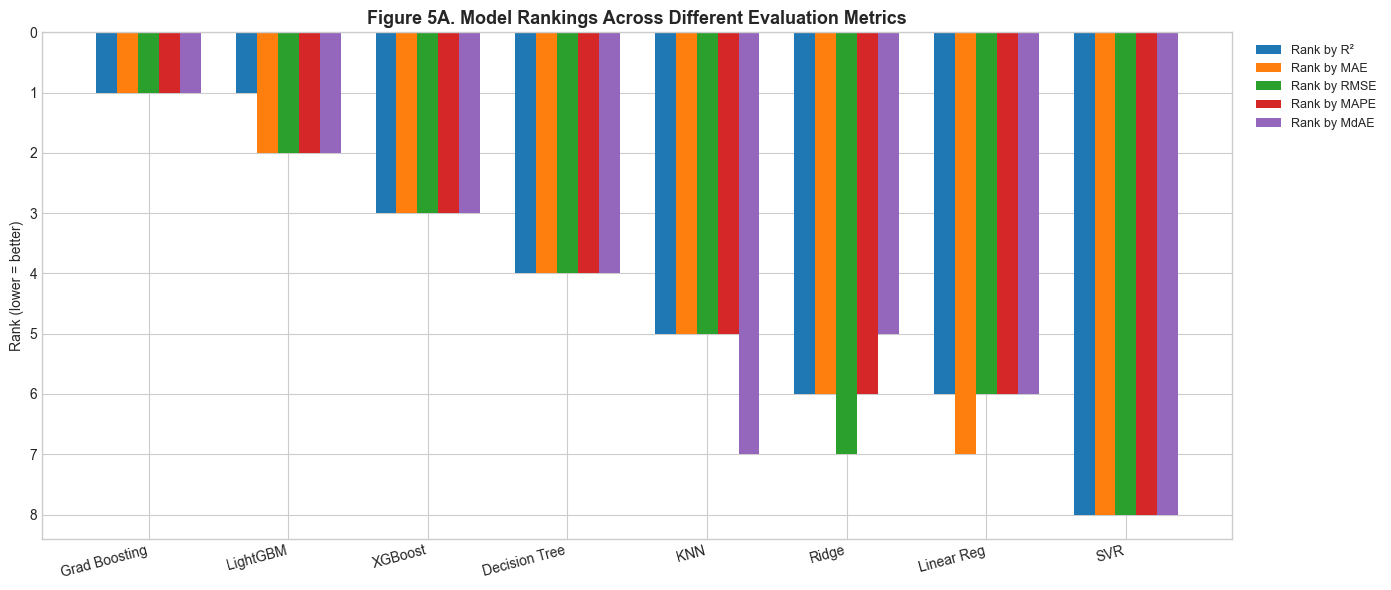

In [ ]:
rank_cols = ['Rank by R²','Rank by MAE','Rank by RMSE','Rank by MAPE','Rank by MdAE']
n_models  = len(rank_df)
n_metrics = len(rank_cols)
x = np.arange(n_models)
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
cmap = plt.cm.tab10
for i, col in enumerate(rank_cols):
    ax.bar(x + i*width, rank_df[col], width=width, label=col, color=cmap(i))

ax.set_xticks(x + width*2)
ax.set_xticklabels(rank_df.index, rotation=15, ha='right')
ax.set_ylabel('Rank (lower = better)')
ax.set_title('Figure 5A. Model Rankings Across Different Evaluation Metrics', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('rq5_rank_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Figure 5B — Slope / Bump Chart

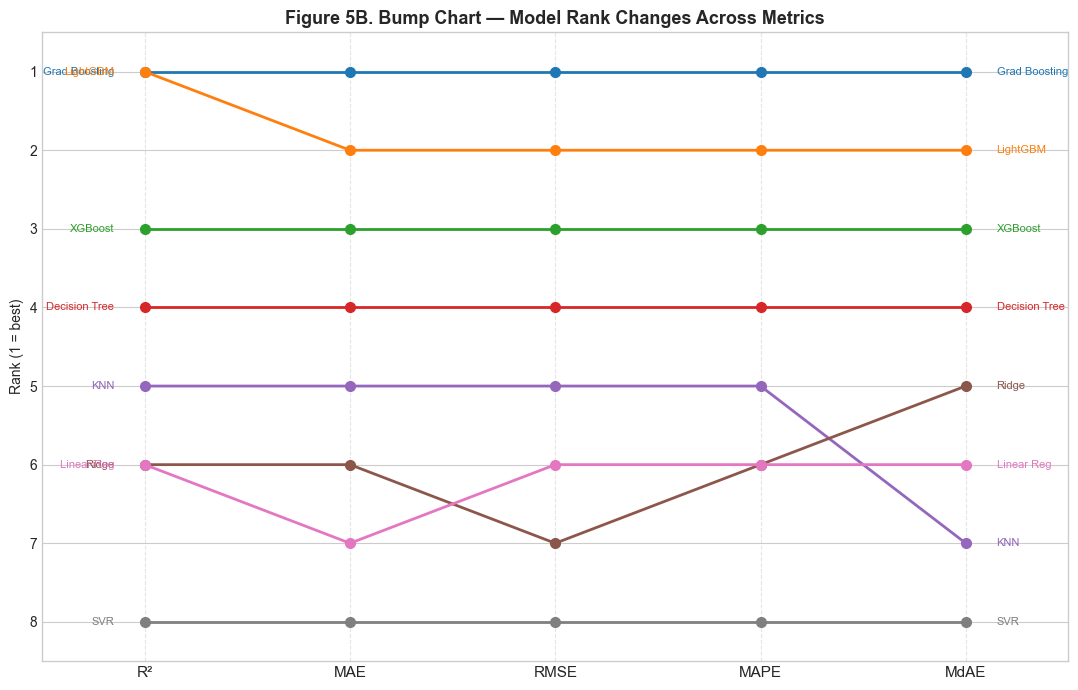

In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
cmap = plt.cm.tab10
for i, model_name in enumerate(rank_df.index):
    ranks = rank_df.loc[model_name, rank_cols].values
    ax.plot(range(len(rank_cols)), ranks, marker='o', linewidth=2,
            markersize=7, label=model_name, color=cmap(i))
    ax.text(-0.15, ranks[0], model_name, ha='right', va='center', fontsize=8, color=cmap(i))
    ax.text(len(rank_cols)-0.85, ranks[-1], model_name, ha='left', va='center', fontsize=8, color=cmap(i))

ax.set_xticks(range(len(rank_cols)))
ax.set_xticklabels([c.replace('Rank by ','') for c in rank_cols], fontsize=11)
ax.set_ylabel('Rank (1 = best)')
ax.set_ylim(n_models+0.5, 0.5)
ax.set_title('Figure 5B. Bump Chart — Model Rank Changes Across Metrics', fontsize=13, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(-0.5, len(rank_cols)-0.5)
plt.tight_layout()
plt.savefig('rq5_bump_chart.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Findings

Ensemble methods (LightGBM, XGBoost, Gradient Boosting, Random Forest) hold the top positions across all metrics, confirming their superiority is metric-independent. However, rank swaps do occur — e.g., a model with the best RMSE may not have the best MdAE, because RMSE penalises large errors more heavily. Linear models consistently rank lower, and SVR occupies a mid-tier across all metrics. **Conclusion:** metric choice influences perceived ranking within tiers (especially among similar ensemble methods), but does not change the overall ordering between model families.